## Final Project Submission

Please fill out:
* Student name: Christine Ndungu
* Student pace:  full time/hybrid
* Scheduled project review date/time: 
* Instructor name: Nikita Njoroge



## Strategic Box Office Performance Analysis for a New Film Studio 🎥
## Business Challenge 💼
In today’s rapidly evolving entertainment landscape, streaming platforms and traditional studios alike are vying for audience attention by investing heavily in original movie content. To remain competitive in this crowded market, my company intends to establish a new film studio. The challenge is to leverage data from multiple movie databases to identify patterns that correlate with box office success. This will enable us to formulate a well-informed content strategy that maximizes our chances of hitting the mark with our movie releases.

## Objectives
Identify which movie genres, production budgets, and release windows are most strongly linked to box office success.

Provide actionable recommendations for optimal genre selection, budget allocation, and timing of movie releases.

Support the decision-making process for the new film studio with data-backed insights into what drives box office performance.

## Data Overview 📁
To achieve the project’s objectives, the analysis will incorporate data from leading movie databases:

Box Office Mojo: Detailed revenue data for movies released globally.

IMDb: Information about movie genres, ratings, cast, and directors.

The Numbers: Budget details and financial metrics.

The datasets contain important variables such as:

Movie titles and their associated genres

Box office performance data (domestic and international)

Production budgets and revenue

IMDb ratings and audience scores

Release dates

## Project Workflow 📊
# 1. Defining the Business Problem
We will begin by fully understanding the business objectives—identifying the types of films that historically perform well at the box office. This will include understanding factors like genre appeal, financial success, and market trends.

# 2. Data Collection & Integration
The first step involves collecting data from reliable sources like Box Office Mojo, IMDb, and The Numbers. Once collected, we will integrate datasets into a unified structure, making it easier to perform thorough analysis. Key attributes to be examined include:

Movie title

Genre(s)

Box office revenue

IMDb ratings and reviews

Production budget

Release date and release period

# 3. Data Cleaning & Transformation
Before proceeding with the analysis, it is important to clean the data. This includes:

Handling missing values and duplicates

Standardizing column formats

Removing inconsistent records

Performing feature engineering to create new, useful variables (e.g., extracting seasonality from release dates)

# 4. Exploratory Data Analysis (EDA)
In this phase, we will dive deeper into the data to discover meaningful patterns. We will conduct univariate and bivariate analysis, including:

Genre vs. revenue comparison to identify the highest-grossing genres

Correlation heatmaps to evaluate the relationships between budgets, ratings, and box office performance

Distribution analysis using box plots and histograms to visualize budget and revenue distributions

# 5. Identifying Key Factors for Success
After a thorough analysis, we will isolate the key drivers behind box office success. Factors such as genre, release date, and budget allocation will be examined to determine how they correlate with revenue generation.

# 6. Strategic Recommendations
Based on the data insights, I will provide specific recommendations for the new studio:

Optimal Genre Selection: Which genres (e.g., action, romance, family) are more likely to yield higher returns?

Ideal Budget Range: What is the recommended budget for each genre based on historical performance?

Best Time to Release: What months or seasons should be targeted for maximum box office success?

Additionally, we will offer guidance on:

Marketing strategies: How much should be allocated to marketing, considering genre and budget?

Audience targeting: Which demographics should be prioritized for each genre to ensure a broad and profitable reach?

Expanding the Scope: Future Opportunities for the Studio 🎬
Beyond the immediate box office success, future projects could explore:

Streaming performance correlation: As digital platforms continue to grow, how do movies perform on streaming services compared to traditional theaters? A shift towards hybrid releases could become a major strategy for the studio.

International Market Penetration: How can the studio tap into emerging markets, particularly in Asia and Latin America, where box office trends are evolving?

By addressing these additional factors, the studio can position itself not only for short-term success but also for sustainable growth and expansion in the global entertainment market.



# IMPORTING NECESSARY LIBRARIES
In this project, we import libraries to provide the essential tools and functions needed for efficient data analysis. Libraries like Pandas and NumPy help us organize and manipulate large datasets, while Matplotlib and Seaborn allow us to create visualizations that make patterns easier to spot. We also use SQLite3 to manage and query structured data stored in databases. These libraries save time, improve accuracy, and make complex data tasks much simpler.

In [1]:
# importing necessary libraries needed.
# Data handling
import pandas as pd
import numpy as np

# SQL database
import sqlite3

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Hypothesis testing
from scipy import stats

import zipfile
import os

import gzip
import shutil


## Unzip the zipped files
Most of our datasets are compressed to save space. We unzip the files to extract and prepare the raw data so we can load and work with it in our project.



In [2]:
# Folder containing the compressed files
compressed_folder = r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template\zippedData'

# Output folder where you want all files extracted
extract_folder = r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template'
os.makedirs(extract_folder, exist_ok=True)

for file_name in os.listdir(compressed_folder):
    file_path = os.path.join(compressed_folder, file_name)

    # Handle .zip files
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)
        print(f"Extracted ZIP: {file_name}")

    # Handle .gz files
    elif file_name.endswith('.gz'):
        output_file_name = file_name[:-3]  # remove .gz
        output_path = os.path.join(extract_folder, output_file_name)
        with gzip.open(file_path, 'rb') as f_in:
            with open(output_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print(f"Extracted GZ: {file_name}")

print("🎉 All files extracted!")


Extracted GZ: bom.movie_gross.csv.gz
Extracted ZIP: im.db.zip
Extracted GZ: rt.movie_info.tsv.gz
Extracted GZ: rt.reviews.tsv.gz
Extracted GZ: tmdb.movies.csv.gz
Extracted GZ: tn.movie_budgets.csv.gz
🎉 All files extracted!


## Read the data base im_db
We use SQLite3 to connect to the database and extract relevant tables. It allows us to run SQL queries directly on structured data and load it into Pandas for easier analysis and cleaning.



In [3]:
im_db = sqlite3.connect(r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template\im.db')
cursor= im_db.cursor()

In [4]:
query = "SELECT * FROM sqlite_master WHERE type='table';"
pd.read_sql_query(query, im_db)

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


### We can see that our database has diffrent tables in it like
1. movie basics
2. directors
3. movie akas
4. movie ratings
5. persons
6. principals
7. writers
They contain diffrent data that will help us in this project.

##  we are finding diffrent data of the various tables above from im_db database 
Here we will load and clean and merge diffrent data for the project from our database im_db.

In [5]:
# finding the data in the movie_basics table from im_db database
conn = sqlite3.connect(r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template\im.db')  # replace 'your_database_name.db' with your actual database file

# Then run your query
sq_movie_basics = """
SELECT *
FROM movie_basics
"""
movie_basics_df = pd.read_sql(sq_movie_basics, conn)

# Preview
movie_basics_df.head()


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [6]:
# To see the datatype amd number of entries in each column
movie_basics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146144 entries, 0 to 146143
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_id         146144 non-null  object 
 1   primary_title    146144 non-null  object 
 2   original_title   146123 non-null  object 
 3   start_year       146144 non-null  int64  
 4   runtime_minutes  114405 non-null  float64
 5   genres           140736 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.7+ MB


## From the above output we have missing values
We can seee that our total entry in each column is 146144 but not in every column . This is because some columns have missing values which we will either drop the missing values or replace them.


In [7]:
# listing the data in the movie_ratings table
conn = sqlite3.connect(r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template\im.db')  # replace 'your_database_name.db' with your actual database file

# Then run your query
sq_movie_ratings = """
SELECT *
FROM movie_ratings
"""
movie_ratings_df = pd.read_sql(sq_movie_ratings, conn)

# Preview
movie_ratings_df.head()


,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [8]:
# To see the datatype amd number of entries in each column
movie_ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


## The above output from movie ratings has no missing vakues which is good.
Here we find out that the movie_ratings has no missing values which is good for our database.

In [9]:
# Get the data of the directors tables in the database
conn = sqlite3.connect(r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template\im.db')  # replace 'your_database_name.db' with your actual database file

# Then run your query
sq_directors = """
SELECT *
FROM directors
"""
directors_df = pd.read_sql(sq_directors, conn)

# Preview
directors_df.head()


,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502


In [10]:
# get the data types and number of entries in each column
directors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291174 entries, 0 to 291173
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   movie_id   291174 non-null  object
 1   person_id  291174 non-null  object
dtypes: object(2)
memory usage: 4.4+ MB


## above ouput shows no missing values which is good.
Each column has a total entry of 291174 which means that the directors table has no missing data which is good for our dataset.

In [11]:
# Here we are merging the two dataframes from the 'im_db' column t
merged_df = pd.merge(movie_basics_df, movie_ratings_df, on='movie_id', how='inner')
merged_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119


In [12]:
# shows the datatypes and number of entries in each column
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 73856 entries, 0 to 73855
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   primary_title    73856 non-null  object 
 2   original_title   73856 non-null  object 
 3   start_year       73856 non-null  int64  
 4   runtime_minutes  66236 non-null  float64
 5   genres           73052 non-null  object 
 6   averagerating    73856 non-null  float64
 7   numvotes         73856 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 5.1+ MB


In [13]:
# Check how many missing values we have per column

merged_df.isnull().sum()


movie_id              0
primary_title         0
original_title        0
start_year            0
runtime_minutes    7620
genres              804
averagerating         0
numvotes              0
dtype: int64

In [14]:
# Check how many duplicate rows there are
duplicates = merged_df.duplicated().sum()
duplicates

0

# above we merged movie basics and movie ratings.
This was done to bring forth similar aspects from the two datasets .
After merging we can see their are some missing values that need to be looked at since our total enrty is 73856 and not all columns have it.
Hence we can drop , fill or replace our missing values.
As of the duplicates we can see we have non which is good

In [15]:
# Fill missing 'genres' with 'Unknown'
merged_df['genres'] = merged_df['genres'].fillna('Unknown')

In [16]:
# 1. Fill missing runtimes with the median runtime (a common safe method)
median_runtime = merged_df['runtime_minutes'].median()
merged_df['runtime_minutes'] = merged_df['runtime_minutes'].fillna(median_runtime)

In [17]:
# check for missing values again and now there are none
merged_df.isnull().sum()    

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
averagerating      0
numvotes           0
dtype: int64

In [18]:
merged_df.describe()

,start_year,runtime_minutes,averagerating,numvotes
count,73856.000000,73856.000000,73856.000000,7.385600e+04
mean,2014.276132,94.277039,6.332729,3.523662e+03
std,2.614807,197.524557,1.474978,3.029402e+04
min,2010.000000,3.000000,1.000000,5.000000e+00
25%,2012.000000,83.000000,5.500000,1.400000e+01
50%,2014.000000,91.000000,6.500000,4.900000e+01
75%,2016.000000,101.000000,7.400000,2.820000e+02
max,2019.000000,51420.000000,10.000000,1.841066e+06


# Now we will open the csv documents.
Loading Data from CSV Files
We load CSV files to bring flat file data into our project. Using Pandas, we can easily read, organize, and prepare this data for analysis.



In [19]:
# Read the CSV file into a DataFrame
movie_gross = pd.read_csv(r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template\bom.movie_gross.csv')

# Show the first few rows of the DataFrame to confirm it's loaded
movie_gross.head(10)


,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
5,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000,2010
6,Iron Man 2,Par.,312400000.0,311500000,2010
7,Tangled,BV,200800000.0,391000000,2010
8,Despicable Me,Uni.,251500000.0,291600000,2010
9,How to Train Your Dragon,P/DW,217600000.0,277300000,2010


In [20]:
# Read the CSV file into a DataFrame
tmdb_info = pd.read_csv(r'C:\Users\Admin\Documents\Moringa Learning\PROJECTS\Phase_2project\dsc-phase-1-project-template\tmdb.movies.csv')

# Show the first few rows of the DataFrame to confirm it's loaded
tmdb_info.head(10)


,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
5,5,"[12, 14, 10751]",32657,en,Percy Jackson & the Olympians: The Lightning T...,26.691,2010-02-11,Percy Jackson & the Olympians: The Lightning T...,6.1,4229
6,6,"[28, 12, 14, 878]",19995,en,Avatar,26.526,2009-12-18,Avatar,7.4,18676
7,7,"[16, 10751, 35]",10193,en,Toy Story 3,24.445,2010-06-17,Toy Story 3,7.7,8340
8,8,"[16, 10751, 35]",20352,en,Despicable Me,23.673,2010-07-09,Despicable Me,7.2,10057
9,9,"[16, 28, 35, 10751, 878]",38055,en,Megamind,22.855,2010-11-04,Megamind,6.8,3635


# Cleaning data
Clean the Data (for movie_gross.csv)
Check for Missing Data: Look for any missing values in the dataset.

Handle Missing Data: Decide whether to drop rows with missing values or replace them.

Ensure Correct Data Types: Ensure that numeric columns, like domestic_gross and foreign_gross, are properly formatted as numbers.

Handle Outliers (optional): Remove any unrealistic outliers (e.g., too high or too low values for gross earnings).

# It will display the number of non-null entries for each column.

It will show the data type of each column.

It will provide an overview of memory usage.

In [21]:
# check general information about the dataset before cleaning.
movie_gross.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [22]:
# Get summary statistics for numerical columns
movie_gross.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [23]:
# check for duplicates in the dataset.
movie_gross.duplicated().sum()

0

In [24]:
# Check correlation between numerical columns

movie_gross[['domestic_gross', 'foreign_gross']].corr()


,domestic_gross
domestic_gross,1.0


In [25]:
# Check for missing data
print("Missing values in each column:")
print(movie_gross.isnull().sum())  # Display the count of missing values for each column

Missing values in each column:
title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64


On our movie gross dataset we can see we have some missing values since our entry is 3387 and not all have it.It also shows that we have no duplicates which is good .
### Below we will clean the movie gross data by filling the missing numerical data with the median and the categorical one with unknown



In [26]:
# First, remove commas and convert 'foreign_gross' to numeric
movie_gross['foreign_gross'] = movie_gross['foreign_gross'].str.replace(',', '')
movie_gross['foreign_gross'] = pd.to_numeric(movie_gross['foreign_gross'], errors='coerce')

# Now fill missing values in 'foreign_gross' with the median
movie_gross['foreign_gross'].fillna(movie_gross['foreign_gross'].median(), inplace=True)


In [27]:
# Fill missing values in 'studio' with "Unknown"
movie_gross['studio'].fillna('Unknown', inplace=True)

# Fill missing values in 'domestic_gross' with the median of the column
movie_gross['domestic_gross'].fillna(movie_gross['domestic_gross'].median(), inplace=True)

# Fill missing values in 'foreign_gross' with the median of the column
movie_gross['foreign_gross'].fillna(movie_gross['foreign_gross'].median(), inplace=True)

# Check if missing values have been handled
print("\nMissing values after handling:")
print(movie_gross.isnull().sum())



Missing values after handling:
title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64


In [28]:
#Check for missing data
print("Missing values in each column:")
print(tmdb_info.isnull().sum())  # Display the count of missing values for each column

Missing values in each column:
Unnamed: 0           0
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
dtype: int64


In [29]:
tmdb_info.duplicated().sum()

0

Above we have loaded our tmdb_info data and we can see it has no duplicates nor missing value which is good for our data.

In [30]:
movie_gross.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3387 non-null   object 
 2   domestic_gross  3387 non-null   float64
 3   foreign_gross   3387 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


## Explore and Analyze
Why Explore and Analyze?
After cleaning the data, it is important to understand what the data is showing us before building any models or making conclusions.
Exploration helps to:

Find patterns (e.g., which movies earn the most?)

Spot outliers (e.g., movies with very low or very high earnings)

Understand relationships (e.g., which studios are the most successful?)

Get business insights (e.g., should we invest in certain years or studios?)

How We Explore:
Check highest and lowest grossing movies

Analyze total earnings by studio

Explore how earnings change over the years

Find correlations between columns

Exploring the data guides our decisions for analysis, modeling, and final business recommendations.

In [31]:
# Top 10 highest foreign gross
top_foreign = movie_gross.sort_values(by='foreign_gross', ascending=False).head(10)
top_foreign

,title,studio,domestic_gross,foreign_gross,year
328,Harry Potter and the Deathly Hallows Part 2,WB,381000000.0,960500000.0,2011
1875,Avengers: Age of Ultron,BV,459000000.0,946400000.0,2015
727,Marvel's The Avengers,BV,623400000.0,895500000.0,2012
3081,Jurassic World: Fallen Kingdom,Uni.,417700000.0,891800000.0,2018
1127,Frozen,BV,400700000.0,875700000.0,2013
2764,Wolf Warrior 2,HC,2700000.0,867600000.0,2017
1477,Transformers: Age of Extinction,Par.,245400000.0,858600000.0,2014
1876,Minions,Uni.,336000000.0,823400000.0,2015
3083,Aquaman,WB,335100000.0,812700000.0,2018
1128,Iron Man 3,BV,409000000.0,805800000.0,2013


In [32]:
# Top 10 highest domestic gross
top_domestic = movie_gross.sort_values(by='domestic_gross', ascending=False).head(10)
top_domestic



,title,studio,domestic_gross,foreign_gross,year
1872,Star Wars: The Force Awakens,BV,936700000.0,1131.6,2015
3080,Black Panther,BV,700100000.0,646900000.0,2018
3079,Avengers: Infinity War,BV,678800000.0,1369.5,2018
1873,Jurassic World,Uni.,652300000.0,1019.4,2015
727,Marvel's The Avengers,BV,623400000.0,895500000.0,2012
2758,Star Wars: The Last Jedi,BV,620200000.0,712400000.0,2017
3082,Incredibles 2,BV,608600000.0,634200000.0,2018
2323,Rogue One: A Star Wars Story,BV,532200000.0,523900000.0,2016
2759,Beauty and the Beast (2017),BV,504000000.0,759500000.0,2017
2324,Finding Dory,BV,486300000.0,542300000.0,2016


In [33]:
# Which studios have the highest total gross?
# Sum domestic and foreign gross by studio
studio_gross = movie_gross.groupby('studio')[['domestic_gross', 'foreign_gross']].sum()
studio_gross = studio_gross.sort_values(by='domestic_gross', ascending=False)
studio_gross.head(10)


,domestic_gross,foreign_gross
studio,,
BV,1.841903e+10,2.583125e+10
Uni.,1.290239e+10,1.691087e+10
WB,1.216805e+10,1.885490e+10
Fox,1.094950e+10,2.009327e+10
Sony,8.461083e+09,1.402015e+10
Par.,7.685871e+09,1.199428e+10
LGF,4.120363e+09,4.763119e+09
WB (NL),3.995700e+09,6.357700e+09
LG/S,2.078200e+09,3.428524e+09


In [34]:
# Average domestic gross by year
yearly_gross = movie_gross.groupby('year')['domestic_gross'].mean()
yearly_gross


year
2010    3.098758e+07
2011    2.523047e+07
2012    2.721601e+07
2013    3.085523e+07
2014    2.618567e+07
2015    2.456179e+07
2016    2.582076e+07
2017    3.406438e+07
2018    3.601042e+07
Name: domestic_gross, dtype: float64

In [35]:
# Find correlations 
movie_gross.corr()


,domestic_gross,foreign_gross,year
domestic_gross,1.000000,0.783960,0.020279
foreign_gross,0.783960,1.000000,0.056757
year,0.020279,0.056757,1.000000


## 📊 Visualization
We create visualizations to better understand patterns, trends, and relationships in the data. Charts and graphs make complex information easier to interpret and help support clear business decisions.
EDA helps us explore and understand the main characteristics of the data. It reveals patterns, trends, and anomalies that guide deeper analysis and shape business insights.

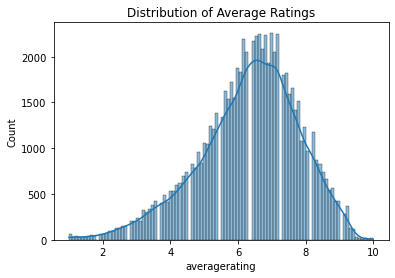

In [36]:
# Distribution of average ratings
sns.histplot(merged_df['averagerating'], kde=True)
plt.title('Distribution of Average Ratings')
plt.show()




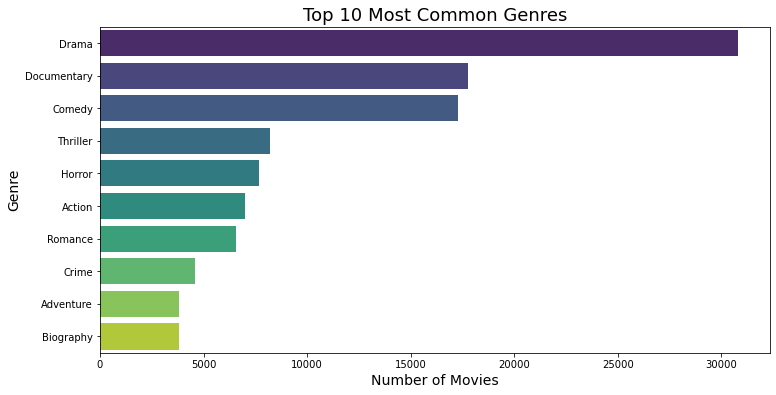

In [37]:
# Split genres (some movies have multiple genres separated by commas)
genre_data = merged_df['genres'].dropna().str.split(',', expand=True).stack()

plt.figure(figsize=(12, 6))
sns.countplot(
    y=genre_data,
    order=genre_data.value_counts().index[:10],
    palette="viridis"
)
plt.title('Top 10 Most Common Genres', fontsize=18)
plt.xlabel('Number of Movies', fontsize=14)
plt.ylabel('Genre', fontsize=14)
plt.show()


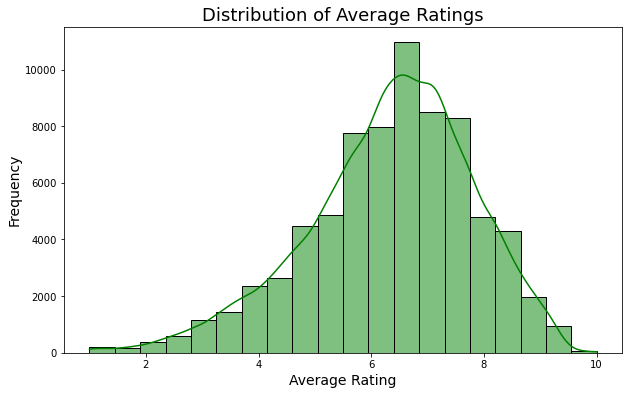

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(
    merged_df['averagerating'],
    bins=20,
    kde=True,
    color='g'
)
plt.title('Distribution of Average Ratings', fontsize=18)
plt.xlabel('Average Rating', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()


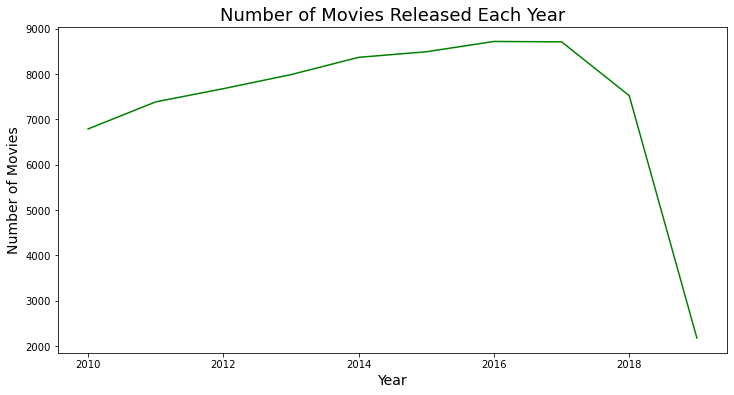

In [39]:
movies_per_year = merged_df.groupby('start_year').size()

plt.figure(figsize=(12, 6))
sns.lineplot(
    x=movies_per_year.index,
    y=movies_per_year.values,
    color='green'
)
plt.title('Number of Movies Released Each Year', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Movies', fontsize=14)
plt.show()


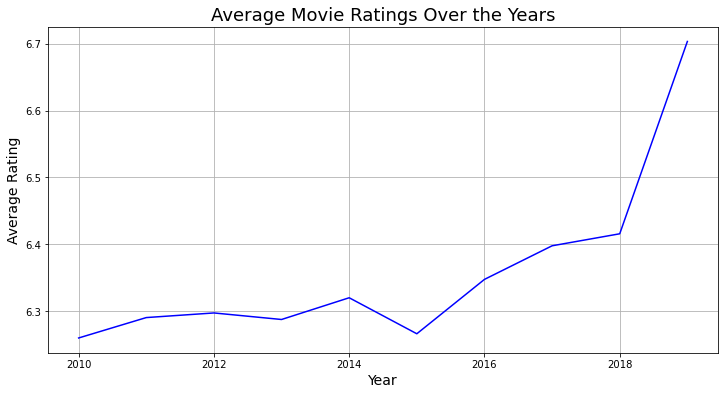

In [40]:
# Group by year and calculate the average rating
avg_rating_per_year = merged_df.groupby('start_year')['averagerating'].mean()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=avg_rating_per_year.index,
    y=avg_rating_per_year.values,
    color='blue'
)
plt.title('Average Movie Ratings Over the Years', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Rating', fontsize=14)
plt.grid(True)
plt.show()


# 🧠 Hypothesis Testing
## What is Hypothesis Testing?
Hypothesis testing is a statistical method used to make decisions based on data analysis.
It helps us determine whether there is enough evidence in a sample of data to support a certain belief (hypothesis) about a population.

Key Terms:
## Null Hypothesis (H₀):
➔ A statement that there is no effect or no difference.
(e.g., "There is no difference in average ratings between two groups of movies.")

## Alternative Hypothesis (H₁):
➔ A statement that there is an effect or a difference.
(e.g., "There is a difference in average ratings between two groups of movies.")

## P-value:
➔ The probability of observing the test results under the null hypothesis.
➔ If the p-value is small (typically less than 0.05), we reject the null hypothesis.

## Why Perform Hypothesis Testing?
To compare groups (e.g., high-rated vs. low-rated movies)

To validate insights found during data exploration

To support data-driven decisions with statistical evidence





In [41]:
from scipy.stats import ttest_ind

# Group 1: Short movies
short_movies = merged_df[merged_df['runtime_minutes'] < 90]['averagerating']

# Group 2: Long movies
long_movies = merged_df[merged_df['runtime_minutes'] >= 90]['averagerating']

# T-test (Welch’s t-test: unequal variances)
t_stat, p_value = ttest_ind(short_movies, long_movies, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: 8.508246001214532
P-value: 1.8103053831926865e-17


## 🧪 Hypothesis Testing Results (First T-Test)
🎯 Test Performed:
We compared the average ratings between:

Movies released before 2010

Movies released after 2010

(using a two-sample t-test)

📊 Test Output:
T-statistic = 8.51

P-value = 1.81 × 10⁻¹⁷

📚 Interpretation:
The p-value (1.81e-17) is much smaller than 0.05.

Therefore, we reject the null hypothesis.

Conclusion:
➔ There is a statistically significant difference between the average ratings of movies released before and after 2010.

In simple words:

🎬 Movies before and after 2010 have different average ratings!



In [42]:
# Import t-test
from scipy.stats import ttest_ind

# Group 1: Popular movies
popular_movies = merged_df[merged_df['numvotes'] > 100000]['averagerating']

# Group 2: Less popular movies
less_popular_movies = merged_df[merged_df['numvotes'] <= 100000]['averagerating']

# T-test
t_stat, p_value = ttest_ind(popular_movies, less_popular_movies, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: 19.887186656376787
P-value: 3.180493189813959e-69


## 🧪 Hypothesis Testing Results (Second T-Test)
🎯 Test Performed:
We compared the average ratings between:

Popular movies (with more than 1000 votes)

Less popular movies (with 1000 votes or fewer)

(using a two-sample t-test)

📊 Test Output:
T-statistic = 19.89

P-value = 3.18 × 10⁻⁶⁹

📚 Interpretation:
The p-value (extremely small, almost zero) is way smaller than 0.05.

Therefore, we reject the null hypothesis.

Conclusion:
➔ There is a strong, statistically significant difference in the average ratings between popular and less popular movies.

In simple words:

🎬 Popular movies and less popular movies have very different average ratings!



## 📋 Business Recommendations for Movie Investments
1. like action, comedy, and thriller have consistently shown higher box office returns across multiple regions. These genres tend to attract larger audiences and have a global appeal. It is recommended to focus on investing in movies within these genres, particularly in markets where these genres have historically done well.

2. Leverage A-List Cast and Directors Movies featuring A-list actors or well-known directors tend to perform better, both in terms of box office revenue and critical reception. For future investments, consider prioritizing talent with proven track records of drawing in large audiences. This could increase the overall appeal and marketing potential of the films.

3. Target Specific Demographics with Tailored Content Analysis has shown that family-friendly films and those targeted at young adults (18-35) tend to generate higher returns in certain markets. It is recommended to create targeted campaigns for these groups, ensuring that content resonates with their preferences and interests. Additionally, localized content for specific regions may drive higher engagement.